# Rebalancing frequency: daily vs monthly vs drift threshold

An equal-weight basket stops being equal weight the day after you buy it: winners grow
into a bigger share of the book and losers shrink. Rebalancing pulls it back to target,
and every rebalancing trade pays the fee. Rebalance too often and fees eat the account;
too rarely and one winner ends up being most of the portfolio.

This notebook runs the same five-coin basket four ways: rebalanced daily, monthly, only
when a coin drifts more than 5pp from its target, and never. It measures each on two
axes, drift (how far the book is from its target) and friction (fees paid), then sweeps
calendar periods and thresholds, checks the result on random baskets, and renders a
video of the four portfolios. Taxes aren't modelled; in a taxable account every
rebalancing sale of a winner is also a realised gain.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from algo_trading.backtest import backtest as bt, data, plots
from algo_trading.backtest.config import FEE_BPS, PortfolioConfig

plots.apply_theme()

TOKENS = ["btc", "eth", "sol", "xrp", "doge"]        # token ids are lowercase
TARGET = pd.Series(1 / len(TOKENS), index=TOKENS)    # equal weight, fully invested
DRIFT = 0.05                   # threshold rule: trade a coin once it is 5pp off target
MONTH = 30                     # days between calendar rebalances; crypto trades every day
WARMUP = 1                     # the initial buy happens on bar 1
FEE = FEE_BPS                  # 0.2% per fill, on every rebalancing trade
INITIAL = 10_000


def rule(check_bars: int = 1, drift: float = 0.0) -> PortfolioConfig:
    """Look at the book every `check_bars` days; once any coin is more than `drift` off
    target, trade every coin back to target."""
    # band is relative to each target; the targets are equal, so one band fits every coin
    return PortfolioConfig(check_bars=check_bars, band=drift / TARGET.min(), band_all=True,
                           min_trade_frac=0.0)


RULES = {"daily": rule(),
         "monthly": rule(MONTH),
         f"±{DRIFT * 100:g}pp drift": rule(drift=DRIFT),
         "never": PortfolioConfig(rebalance=False)}   # buy once, let it drift
THRESH = list(RULES)[2]
COLORS = [plots.color(i) for i in (0, 2, 3, 1)]       # never gets the buy & hold colour
TOKEN_COLORS = [plots.color(i) for i in range(len(TOKENS))]

## Data

In [2]:
panel = data.daily_panel(TOKENS)
close = panel.close[TOKENS].dropna()        # start once every coin has a price
target = pd.DataFrame([TARGET] * len(close), index=close.index)   # same split every bar
print(panel.describe())
print(f"trading {close.index[WARMUP]:%Y-%m-%d} -> {close.index[-1]:%Y-%m-%d}")

1,096 1d bars x 5 tokens  2023-01-01 00:00:00+00:00 -> 2025-12-31 00:00:00+00:00
trading 2023-01-02 -> 2025-12-31


## Passive drift

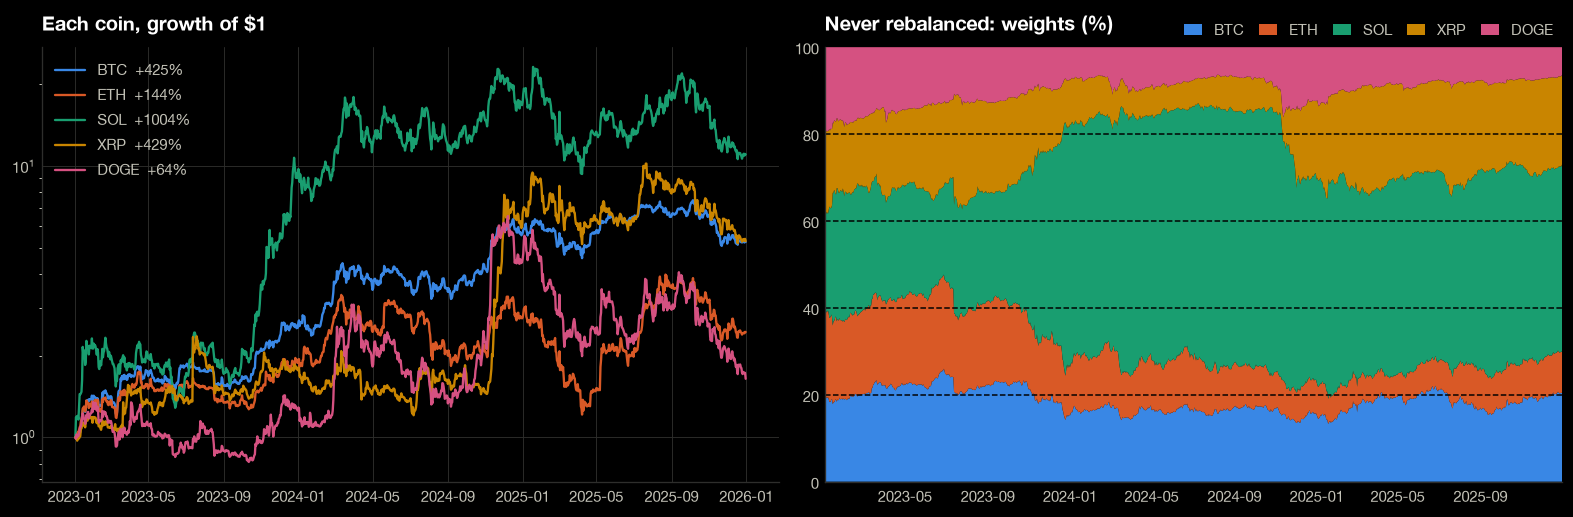

never rebalanced, final weights: BTC 20%, ETH 10%, SOL 43%, XRP 21%, DOGE 6%; largest drift 42%


In [3]:
def run(cfg: PortfolioConfig, px: pd.DataFrame = close, tgt: pd.DataFrame = target) -> dict:
    return bt.simulate(px, tgt, cfg, fee_bps=FEE, initial=INITIAL, warmup=WARMUP)


def drift(w: pd.DataFrame, tgt: pd.Series = TARGET) -> pd.Series:
    """The largest gap between any coin's weight and its target, bar by bar."""
    return (w - tgt).abs().max(axis=1).iloc[WARMUP:]


def fees_paid(res: dict, index: pd.Index = close.index) -> pd.Series:
    """Cumulative fees, in dollars."""
    return res["fills"].groupby("ts").fee.sum().reindex(index, fill_value=0).cumsum()


def stack(ax, w: pd.DataFrame, title: str) -> None:
    """Held weights as a stacked area, with the target split dashed."""
    w = w.iloc[WARMUP:]
    ax.stackplot(w.index, w[TOKENS].T * 100, colors=TOKEN_COLORS,
                 labels=[t.upper() for t in TOKENS], lw=0)
    for v in TARGET.cumsum().iloc[:-1] * 100:
        ax.axhline(v, color=plt.rcParams["axes.facecolor"], lw=0.9, ls="--")
    ax.set_ylim(0, 100)
    ax.set_xlim(w.index[0], w.index[-1])
    ax.grid(False)
    ax.set_title(title)


runs = {label: run(cfg) for label, cfg in RULES.items()}
held = {label: bt.held_weights(res, close) for label, res in runs.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), layout="constrained")
growth = close.iloc[WARMUP:] / close.iloc[WARMUP]
for tok, col in zip(TOKENS, TOKEN_COLORS):
    axes[0].plot(growth.index, growth[tok], color=col, lw=1.4,
                 label=f"{tok.upper()}  {growth[tok].iloc[-1] - 1:+.0%}")
axes[0].set_yscale("log")
axes[0].set_title("Each coin, growth of $1")
axes[0].legend(loc="upper left")
stack(axes[1], held["never"], "Never rebalanced: weights (%)")
axes[1].legend(loc="lower right", bbox_to_anchor=(1.0, 1.0), ncol=len(TOKENS), borderaxespad=0.2,
               handlelength=1.2, columnspacing=1.0)
plt.show()

w_end = held["never"].iloc[-1]
print("never rebalanced, final weights: "
      + ", ".join(f"{t.upper()} {w_end[t]:.0%}" for t in TOKENS)
      + f"; largest drift {drift(held['never']).max():.0%}")

## Backtest

In [4]:
def row(label: str, res: dict, w: pd.DataFrame) -> dict:
    trade_days = res["fills"].ts.nunique() - 1                 # the initial buy isn't one
    d = drift(w)
    return bt.stats_from_result(res, label, WARMUP, panel.bars_per_year) | {
        "final_$": res["equity"].iloc[-1], "fees_$": res["fees"], "rebalances": trade_days,
        "avg_drift": d.mean(), "max_drift": d.max(), "max_wt": w.iloc[WARMUP:].max().max()}


table = pd.DataFrame([row(k, runs[k], held[k]) for k in RULES]).set_index("label")
bt.fmt_table(table[["final_$", "total_ret", "sharpe", "vol", "max_dd", "rebalances", "n_fills",
                    "fees_$", "turnover", "avg_drift", "max_drift", "max_wt"]],
             {**bt.PERF_FMT, "final_$": "${:,.0f}", "fees_$": "${:,.0f}",
              "rebalances": "{:.0f}", "avg_drift": "{:.1%}", "max_drift": "{:.1%}",
              "max_wt": "{:.0%}"})

,final_$,total_ret,sharpe,vol,max_dd,rebalances,n_fills,fees_$,turnover,avg_drift,max_drift,max_wt
label,,,,,,,,,,,,
daily,"$52,447",+425.5%,1.19,63%,-51.2%,1094,5475,"$1,360",68.0x,0.0%,0.0%,20%
monthly,"$58,567",+486.8%,1.24,64%,-51.3%,36,185,$406,20.3x,2.5%,15.5%,35%
±5pp drift,"$55,168",+452.8%,1.22,63%,-51.2%,22,115,$271,13.5x,2.8%,5.0%,25%
never,"$51,228",+413.3%,1.15,67%,-52.7%,0,5,$20,1.0x,23.7%,41.9%,62%


## Allocation over time

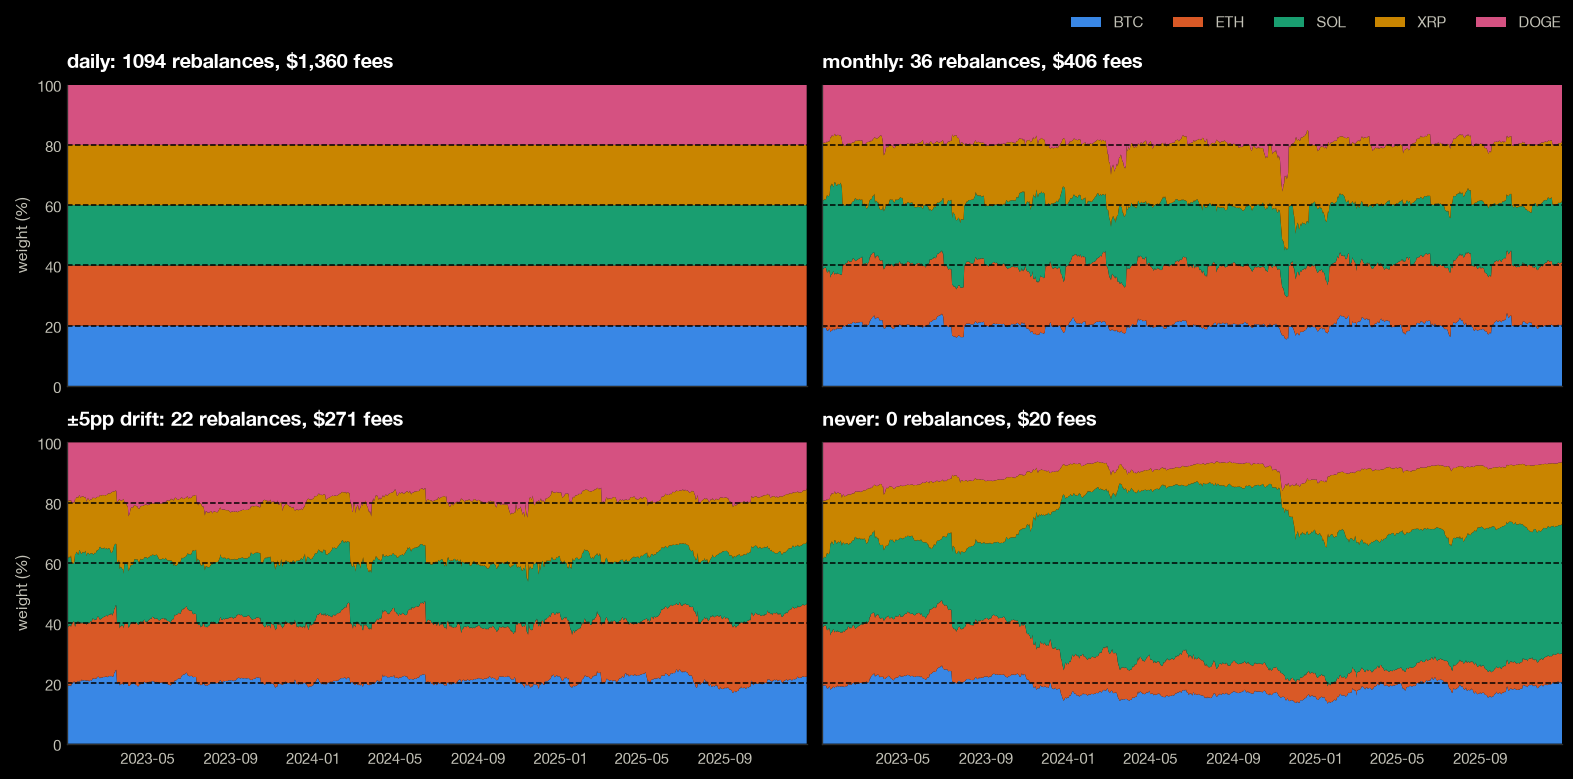

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6.4), layout="constrained", sharex=True, sharey=True)
for ax, label in zip(axes.flat, RULES):
    stack(ax, held[label], f"{label}: {table.rebalances[label]:.0f} rebalances, "
                           f"${table['fees_$'][label]:,.0f} fees")
for ax in axes[:, 0]:
    ax.set_ylabel("weight (%)")
fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="outside upper right", ncol=len(TOKENS))
plt.show()

## Cost vs drift

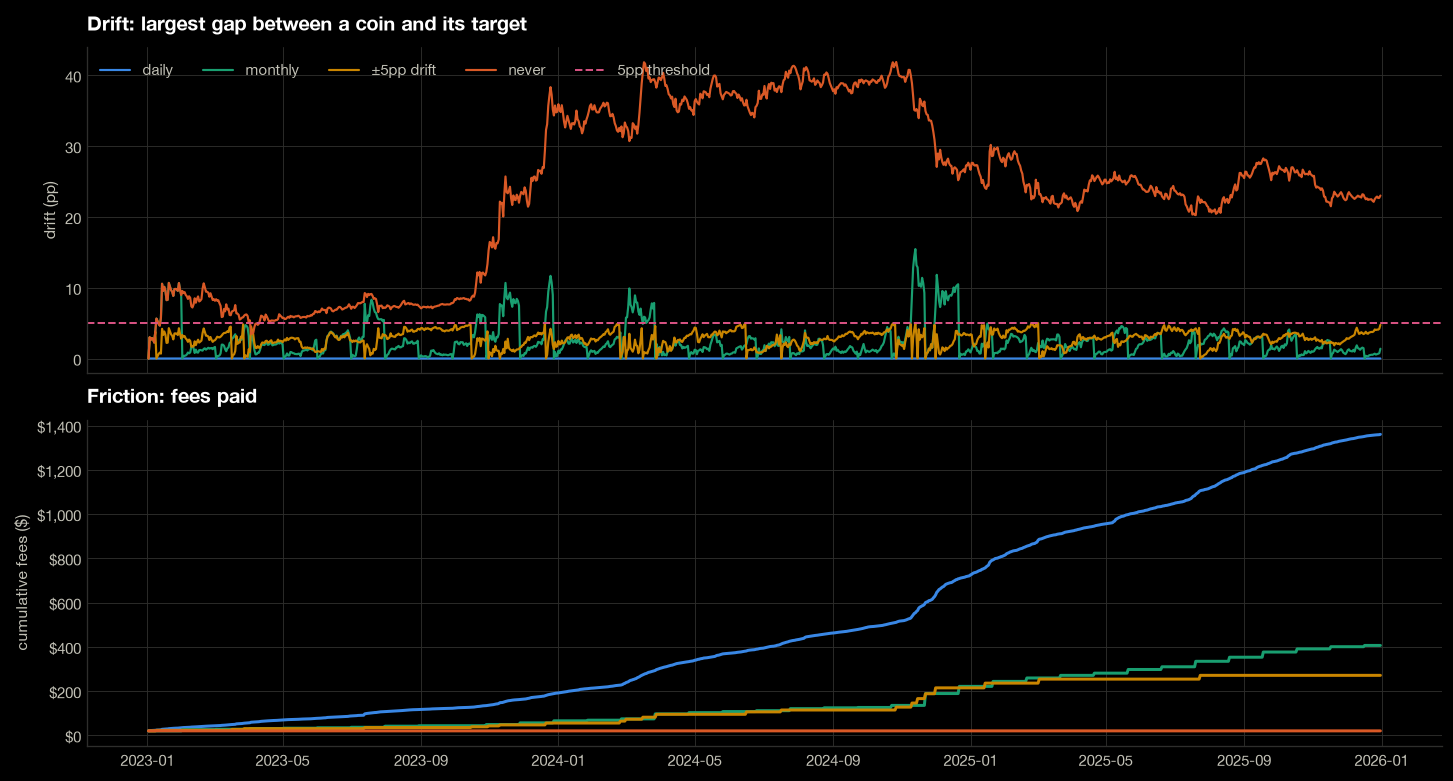

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6.4), layout="constrained", sharex=True)
for label, col in zip(RULES, COLORS):
    axes[0].plot(drift(held[label]) * 100, color=col, lw=1.3, label=label)
    axes[1].plot(fees_paid(runs[label]).iloc[WARMUP:], color=col, lw=1.8, label=label)
axes[0].axhline(DRIFT * 100, color=plots.color(4), ls="--", lw=1.2, label=f"{DRIFT * 100:g}pp threshold")
axes[0].set_title("Drift: largest gap between a coin and its target")
axes[0].set_ylabel("drift (pp)")
axes[0].legend(loc="upper left", ncol=5)
axes[1].set_title("Friction: fees paid")
axes[1].set_ylabel("cumulative fees ($)")
axes[1].yaxis.set_major_formatter(lambda v, _: f"${v:,.0f}")
plt.show()

## Equity

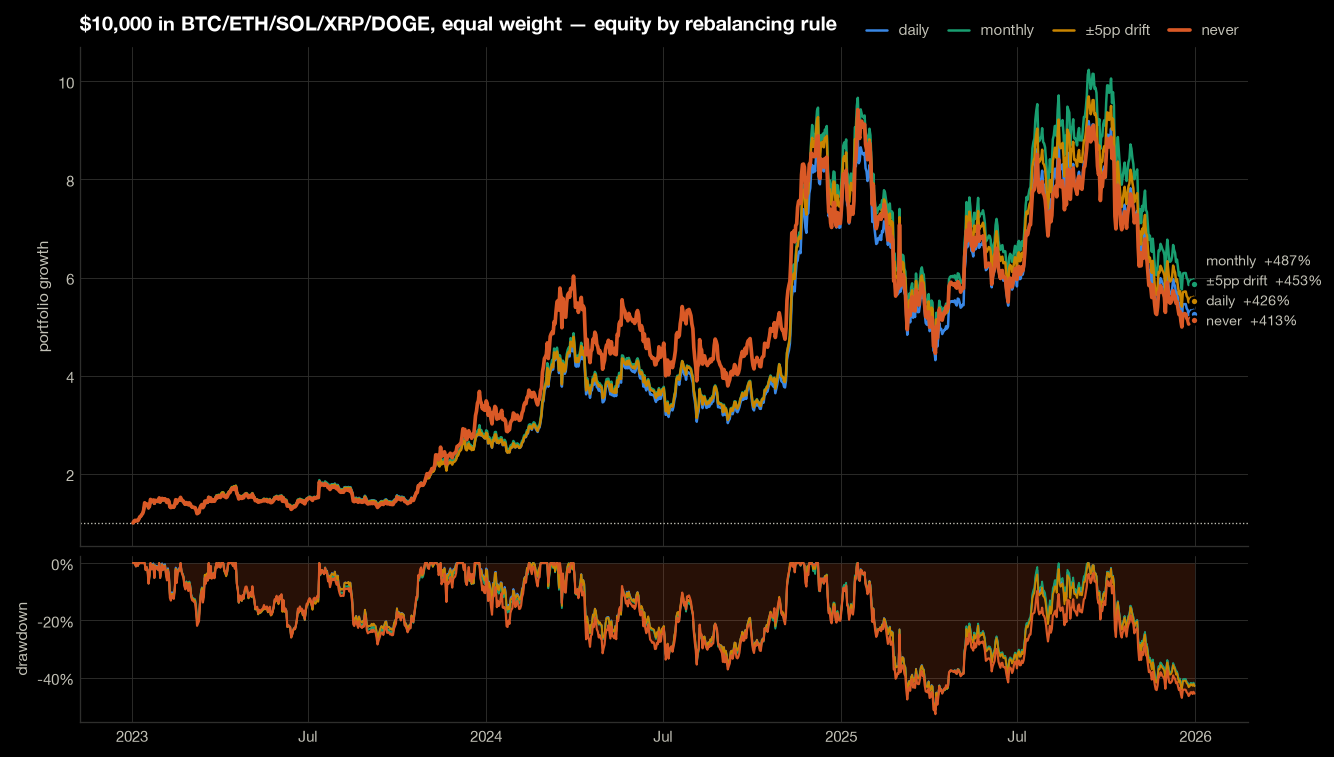

In [7]:
plots.equity_drawdown({k: runs[k]["equity"].iloc[WARMUP:] for k in RULES},
                      f"${INITIAL:,.0f} in {'/'.join(t.upper() for t in TOKENS)}, equal weight — "
                      "equity by rebalancing rule",
                      colors=COLORS, dd_for="never")
plt.show()

## The trade-off: calendar period vs drift threshold

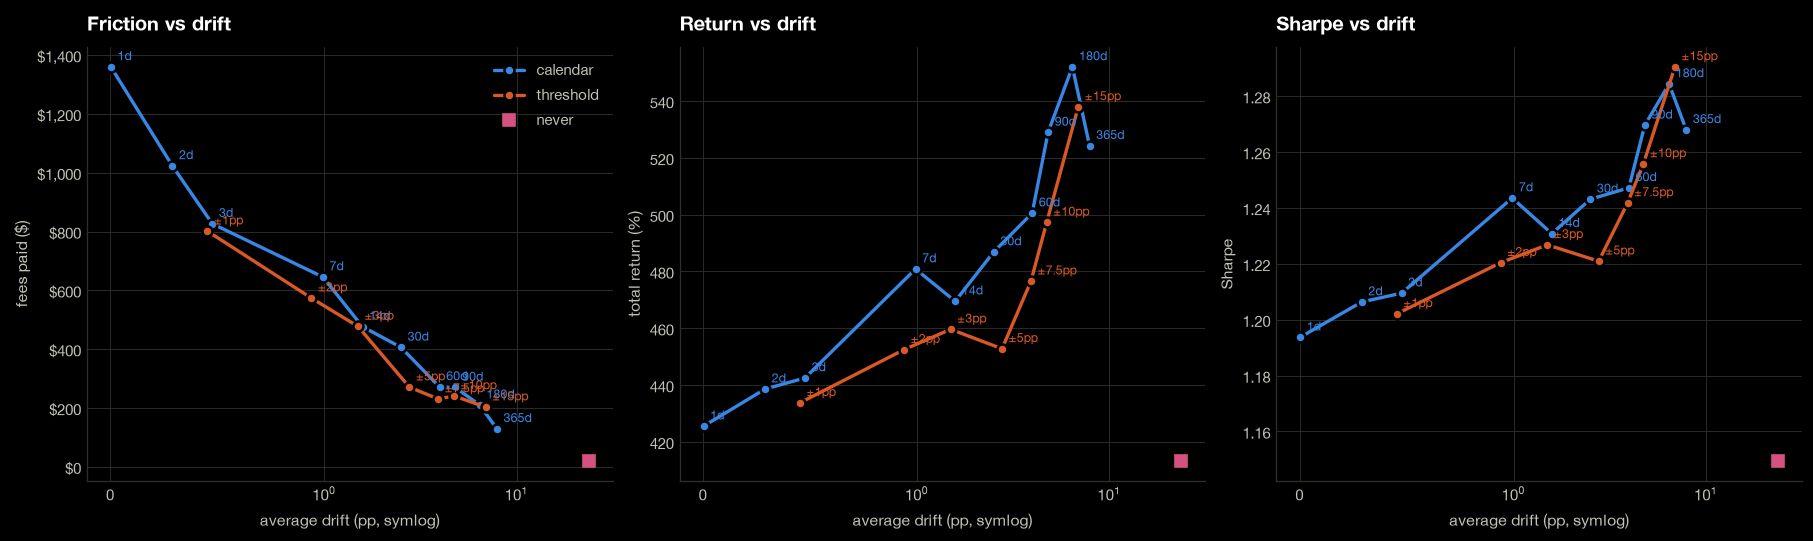

                      fees  avg_drift     ret  sharpe
calendar  1.000    1360.17       0.00  425.52    1.19
          2.000    1023.52       0.29  438.60    1.21
          3.000     826.72       0.48  442.50    1.21
          7.000     645.50       0.99  480.87    1.24
          14.000    476.48       1.58  469.52    1.23
          30.000    406.10       2.50  486.84    1.24
          60.000    271.57       3.97  500.55    1.25
          90.000    269.60       4.80  528.99    1.27
          180.000   209.86       6.43  552.06    1.28
          365.000   129.22       7.89  524.27    1.27
threshold 0.010     801.39       0.45  433.77    1.20
          0.020     573.71       0.94  452.50    1.22
          0.030     477.40       1.50  459.64    1.23
          0.050     270.90       2.77  452.79    1.22
          0.075     230.53       3.91  476.59    1.24
          0.100     240.83       4.72  497.32    1.26
          0.150     203.01       6.89  537.97    1.29


In [8]:
PERIODS = [1, 2, 3, 7, 14, 30, 60, 90, 180, 365]              # days between rebalances
THRESHOLDS = [0.01, 0.02, 0.03, 0.05, 0.075, 0.10, 0.15]    # drift that triggers a trade


def point(cfg: PortfolioConfig) -> dict:
    res = run(cfg)
    w = bt.held_weights(res, close)
    return {"fees": res["fees"], "avg_drift": drift(w).mean() * 100,
            "ret": (res["equity"].iloc[-1] / res["equity"].iloc[WARMUP] - 1) * 100,
            "sharpe": bt.stats_from_result(res, "", WARMUP, panel.bars_per_year)["sharpe"]}


frontier = {"calendar": pd.DataFrame([point(rule(p)) for p in PERIODS], index=PERIODS),
            "threshold": pd.DataFrame([point(rule(drift=d)) for d in THRESHOLDS],
                                      index=THRESHOLDS)}
never = point(RULES["never"])
tag = {"calendar": lambda p: f"{p}d", "threshold": lambda d: f"±{d * 100:g}pp"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), layout="constrained")
for ax, (y, ylabel, title) in zip(axes, [("fees", "fees paid ($)", "Friction vs drift"),
                                         ("ret", "total return (%)", "Return vs drift"),
                                         ("sharpe", "Sharpe", "Sharpe vs drift")]):
    for i, (name, f) in enumerate(frontier.items()):
        ax.plot(f.avg_drift, f[y], marker="o", ms=6, color=plots.color(i),
                mec=plt.rcParams["axes.facecolor"], mew=1.5, label=name)
        for k, r in f.iterrows():
            ax.annotate(tag[name](k), (r.avg_drift, r[y]), xytext=(4, 4),
                        textcoords="offset points", fontsize=7.5, color=plots.color(i))
    ax.plot(never["avg_drift"], never[y], marker="s", ms=7, color=plots.color(4),
            ls="none", label="never")
    ax.set_xscale("symlog", linthresh=1)
    ax.set_xlabel("average drift (pp, symlog)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
axes[0].yaxis.set_major_formatter(lambda v, _: f"${v:,.0f}")
axes[0].legend(loc="upper right")
plt.show()

print(pd.concat({k: f.round(2) for k, f in frontier.items()}).to_string())

## Other baskets

One basket is one draw of history. Here the four rules run on random five-coin,
equal-weight baskets drawn from every coin with a price on every bar of the same
window.

In [9]:
N_BASKETS, SEED = 200, 0

full = data.daily_panel().close.reindex(close.index)     # the same bars as above
pool = sorted(full.columns[full.notna().all()])
rng = np.random.default_rng(SEED)
baskets = [sorted(rng.choice(pool, len(TOKENS), replace=False)) for _ in range(N_BASKETS)]
print(f"{len(pool)} coins with a full history: {', '.join(pool)}")

rows = []
for b in baskets:
    px = full[b]
    tgt_w = pd.Series(1 / len(b), index=b)
    tgt = pd.DataFrame([tgt_w] * len(px), index=px.index)
    for label, cfg in RULES.items():
        res = run(cfg, px, tgt)
        w = bt.held_weights(res, px)
        rows.append({"basket": "/".join(b), "rule": label, "fees": res["fees"],
                     "ret": res["equity"].iloc[-1] / res["equity"].iloc[WARMUP] - 1,
                     "avg_drift": drift(w, tgt_w).mean(), "max_wt": w.iloc[WARMUP:].max().max(),
                     **{k: v for k, v in bt.stats_from_result(res, "", WARMUP,
                                                              panel.bars_per_year).items()
                        if k in ("sharpe", "max_dd")}})
multi = pd.DataFrame(rows)

med = multi.groupby("rule", sort=False)[["ret", "sharpe", "max_dd", "fees", "avg_drift",
                                         "max_wt"]].median()
by = {k: multi[multi.rule == k].set_index("basket") for k in RULES}
for k in RULES:
    med.loc[k, "beats_daily"] = (by[k].ret > by["daily"].ret).mean()
    med.loc[k, "beats_never"] = (by[k].ret > by["never"].ret).mean()
print(f"median over {N_BASKETS} random baskets")
bt.fmt_table(med, {"ret": "{:+.0%}", "sharpe": "{:.2f}", "max_dd": "{:.0%}", "fees": "${:,.0f}",
                   "avg_drift": "{:.1%}", "max_wt": "{:.0%}", "beats_daily": "{:.0%}",
                   "beats_never": "{:.0%}"})

24 coins with a full history: aave, ada, algo, atom, avax, bch, btc, doge, dot, etc, eth, icp, link, ltc, near, qnt, shib, sol, trx, uni, xlm, xmr, xrp, zec
median over 200 random baskets


,ret,sharpe,max_dd,fees,avg_drift,max_wt,beats_daily,beats_never
rule,,,,,,,,
daily,+136%,0.76,-59%,$900,0.0%,20%,0%,38%
monthly,+152%,0.79,-59%,$227,2.6%,41%,88%,56%
±5pp drift,+153%,0.80,-59%,$237,2.4%,25%,98%,50%
never,+155%,0.82,-57%,$20,14.8%,54%,62%,0%


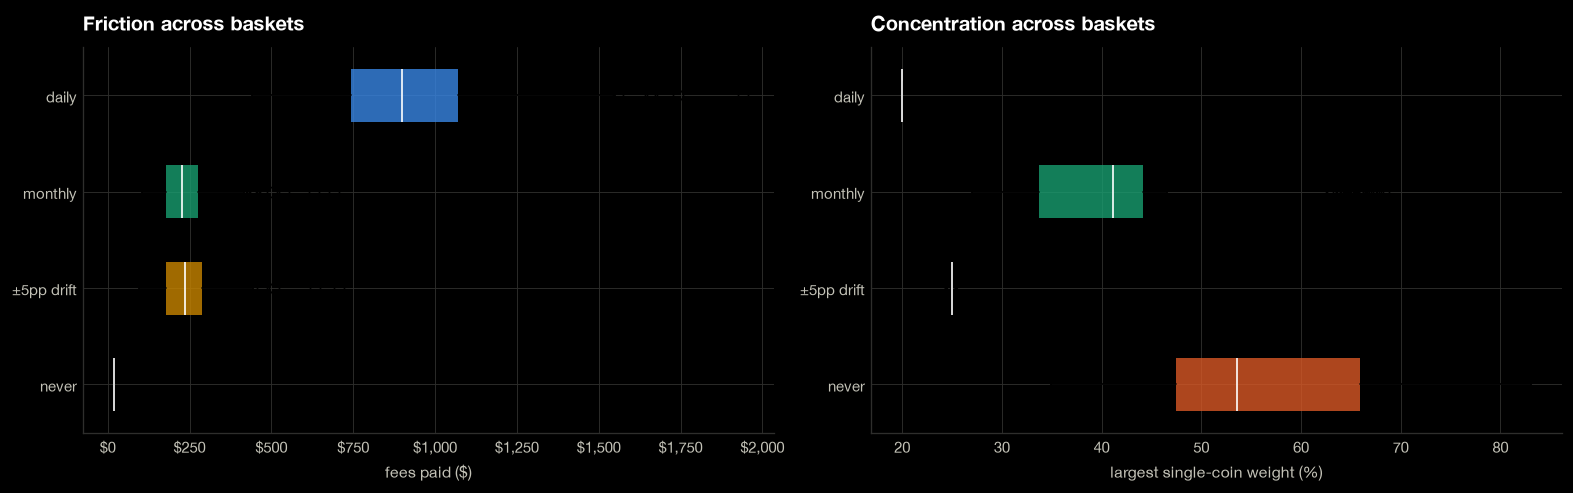

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), layout="constrained")
for ax, (col, xlabel) in zip(axes, [("fees", "fees paid ($)"), ("max_wt", "largest single-coin weight")]):
    data_ = [by[k][col] * (100 if col == "max_wt" else 1) for k in RULES]
    parts = ax.boxplot(data_, orientation="horizontal", tick_labels=list(RULES), patch_artist=True,
                       widths=0.55, medianprops={"color": plt.rcParams["text.color"]})
    for patch, c in zip(parts["boxes"], COLORS):
        patch.set(facecolor=c, alpha=0.8, lw=0)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel + (" (%)" if col == "max_wt" else ""))
axes[0].set_title("Friction across baskets")
axes[1].set_title("Concentration across baskets")
axes[0].xaxis.set_major_formatter(lambda v, _: f"${v:,.0f}")
plt.show()

Reading the results: fees fall steeply as rebalancing gets less frequent, and drift
rises, but the two rules spend their trades differently. A calendar rule trades on the
date whether or not anything has drifted, and lets a big move run until the next date; a
threshold rule trades only when the book is actually off target, so it caps the worst
drift for a similar fee bill. Never rebalancing is cheapest and, in a market this
trend-driven, often returns as much, but it does so by letting one or two coins become
most of the portfolio.

## Video: four portfolios, one basket

Two parts, joined: the four equity curves drawing in with fees paid underneath, then a
still of what each rule actually held over the whole period.

In [11]:
import os
import tempfile
from pathlib import Path

from IPython.display import Video

from algo_trading.backtest import animate
from algo_trading.backtest.config import PROJECT_ROOT

BRAND = PROJECT_ROOT.parent / "public"   # local brand assets; not part of this repo
FONT = BRAND / "fonts" / "alliance-no1" / "Degarism Studio - Alliance No.1 Light.otf"
ICON = BRAND / "hpt-icon-purple.png"
font = FONT if FONT.exists() else None

AUDIO = PROJECT_ROOT / ".audio" / "NEMZZZ - 4AM [OFFICIAL VIDEO] - Nemzzz (192k).mp3"
AUDIO_START = 30.0           # seconds into the track to start from

span = close.index[WARMUP:]
basket = (f"${INITIAL:,.0f} split evenly: {'/'.join(t.upper() for t in TOKENS)} · "
          f"{FEE / 100:g}% fee")
thr, day = table.loc[THRESH], table.loc["daily"]
best = table.total_ret.drop("never").idxmax()

with tempfile.TemporaryDirectory() as tmp:
    race = animate.equity_race(
        {k: runs[k]["equity"].loc[span] for k in RULES}, Path(tmp) / "race.mp4",
        title="How often should you rebalance?", subtitle=basket,
        caption=f"Daily paid ${day['fees_$']:,.0f} in fees; {best} ended "
                f"{table.total_ret[best]:+.0%}.",
        log=False, colors=COLORS, dd_for="daily",
        fees={k: fees_paid(runs[k]).loc[span] for k in RULES},
        font=font, icon=ICON if ICON.exists() else None, progress=False)
    still = animate.allocation_still(
        {k: held[k].loc[span] for k in RULES},
        {k: fees_paid(runs[k]).loc[span] for k in RULES},
        {k: runs[k]["equity"].loc[span] for k in RULES},
        TARGET, Path(tmp) / "still.mp4",
        title="What each rule held", subtitle=basket,
        caption=f"Never rebalanced: {table.max_wt['never']:.0%} in one coin. "
                f"±{DRIFT * 100:g}pp rule: ${thr['fees_$']:,.0f} fees.",
        threshold=DRIFT, colors=TOKEN_COLORS, font=font)
    video = animate.concat([race, still], PROJECT_ROOT / ".media" / "rebal_freq.mp4",
                           audio=AUDIO, audio_start=AUDIO_START)

Video(os.path.relpath(video), embed=False, width=540)